## Random Forest (Regression)

Random Forest Regressor is a machine learning algorithm used to predict continuous numerical values (e.g., a transaction amount, a house price, or a salary). It is the regression counterpart to the Random Forest Classifier, and belongs to the same family of ensemble learning methods.

Instead of voting on a category (like "Fraud" or "Normal"), the trees in a regressor each predict a number, and the final output is the average of all those predictions.

1 Setup libraries

In [1]:
import pandas as pd
import joblib
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

file_path = "../data/data_2/data_labeled.json"

2 Load data

Reads the labeled dataset (data_labeled.json) and shows a preview of the first rows.

In [2]:
df = pd.read_json(file_path)
df.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Gender,Location,...,Transaction Count,Working Status,Salary (per month),Age,Balance_to_Salary_Ratio,Transaction_to_Balance_Ratio,Hour,DayOfWeek,is_fraud,anomaly_score
0,TXN_300001,ACC_06255,REC_3912,0.436816,2025-11-17 07:34:00,3,1,4,2,1,...,10,2,0.177778,0.414634,0.097504,0.003572,7,0,0,-0.539102
1,TXN_300002,ACC_04472,REC_7262,0.168972,2025-08-13 07:31:00,1,1,3,1,6,...,3,5,0.355556,0.170732,0.021225,0.003929,7,2,0,-0.517723
2,TXN_300003,ACC_00398,REC_3277,0.309114,2025-01-24 15:14:00,1,1,3,0,0,...,4,5,0.266667,0.463415,0.096282,0.001959,15,4,0,-0.482311
3,TXN_300004,ACC_06061,REC_4510,0.923370,2025-08-16 20:45:00,6,2,2,2,6,...,2,2,0.933333,0.926829,0.049164,0.004124,20,5,0,-0.514468
4,TXN_300005,ACC_09143,REC_4206,0.368501,2025-05-06 21:27:00,0,2,2,0,5,...,2,3,0.377778,0.048780,0.170282,0.001018,21,1,0,-0.502332


3 Select features and Preprocessing data

Picks the input columns the model uses to predict transaction amounts — customer info like salary, account balance, location, job status, and time-of-day features. Any missing values are filled with the column's median to avoid errors.

Key difference from the classifier: The target y here is Transaction amount (a number), not is_fraud (a yes/no label).








In [3]:
feature_cols = [
    'Salary (per month)', 'Account balance', 'Transaction Count',
    'Working Status', 'Hour', 'DayOfWeek', 'Transaction Detail',
    'Location', 'Geological', 'Gender', 'Age', 'Is_Weekend', 'Is_Night',
    'Balance_to_Salary_Ratio', 'Transaction_to_Balance_Ratio'
]

available = [col for col in feature_cols if col in df.columns]
X = df[available].copy()
y = df['Transaction amount']

X = X.fillna(X.median(numeric_only=True))

4 Train model and split data

Splits data 80/20 for training and testing, then trains the Random Forest Regressor with 100 trees to learn the relationship between customer habits and how much they typically spend.



In [4]:
   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
    

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


5 Evaluate

Runs predictions on the test set and prints three error metrics:

Mean Absolute Error (MAE): The average absolute difference between predicted and actual values. Easy to interpret — it is measured in the same unit as the target (e.g., dollars).

Mean Squared Error (MSE): Like MAE, but squares the errors first. This penalizes large errors more heavily.

R-squared (R²): Measures how much of the variance in the target variable the model explains. A score of 1.0 is perfect; a score of 0.0 means the model is no better than predicting the mean.



Also prints a ranked list of which features influenced predictions the most.

In [5]:
preds = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"MSE: {mean_squared_error(y_test, preds):.2f}")
print(f"R2:  {r2_score(y_test, preds):.4f}")

importances = sorted(zip(available, model.feature_importances_), key=lambda x: x[1], reverse=True)
print("Feature Importances:")
for name, score in importances:
    print(f"  {name:<25} {score:.4f}")


MAE: 0.00
MSE: 0.00
R2:  0.9988
Feature Importances:
  Transaction_to_Balance_Ratio 0.7744
  Account balance           0.2230
  Balance_to_Salary_Ratio   0.0009
  Age                       0.0003
  Hour                      0.0002
  Salary (per month)        0.0002
  Geological                0.0002
  Transaction Count         0.0002
  DayOfWeek                 0.0002
  Transaction Detail        0.0002
  Working Status            0.0001
  Location                  0.0001
  Gender                    0.0001


6 Visualization


6.1 Actual vs Predicted

Each dot is one transaction. The closer the dots are to the red diagonal line, the better the model's predictions

Text(0.5, 1.0, 'Actual vs Predicted Transaction Amount')

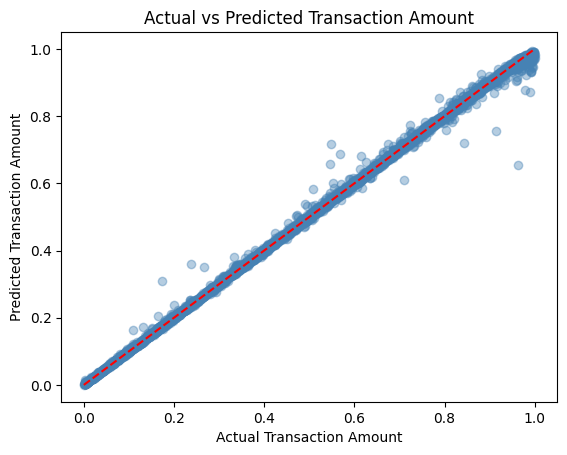

In [6]:
errors = y_test.values - preds

# 1. Actual vs Predicted
plt.figure()
plt.scatter(y_test, preds, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Transaction Amount')
plt.ylabel('Predicted Transaction Amount')
plt.title('Actual vs Predicted Transaction Amount')

5.2 Feature Importances

Horizontal bar chart ranking which customer habits (salary, balance, location…) most influence the predicted transaction amount

Text(0.5, 1.0, 'Feature Importances (Customer Habits)')

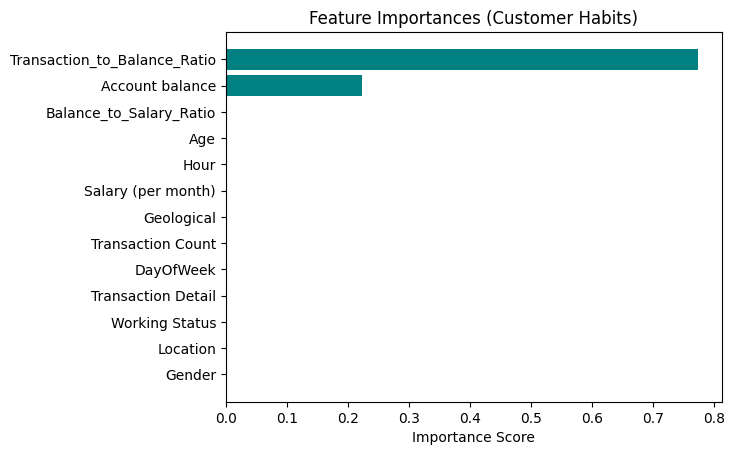

In [7]:
# 2. Feature Importances
plt.figure()
importances = sorted(zip(available, model.feature_importances_), key=lambda x: x[1])
names, scores = zip(*importances)
plt.barh(names, scores, color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importances (Customer Habits)')


5.3 Prediction Error Distribution

Histogram of how far off the predictions were — ideally centered around 0

Text(0.5, 1.0, 'Prediction Error Distribution')

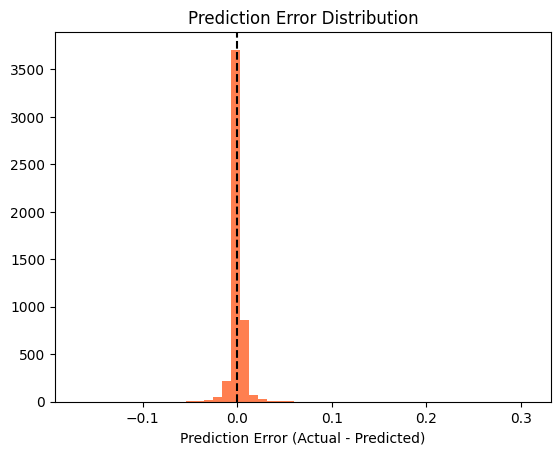

In [8]:
# 3. Prediction Error Distribution
plt.figure()
plt.hist(errors, bins=50, color='coral')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.title('Prediction Error Distribution')


5.4 Residuals vs Predicted

Scatter plot checking if errors are random (good) or show a pattern (meaning the model is systematically wrong in some range)

Text(0.5, 1.0, 'Residuals vs Predicted Amount')

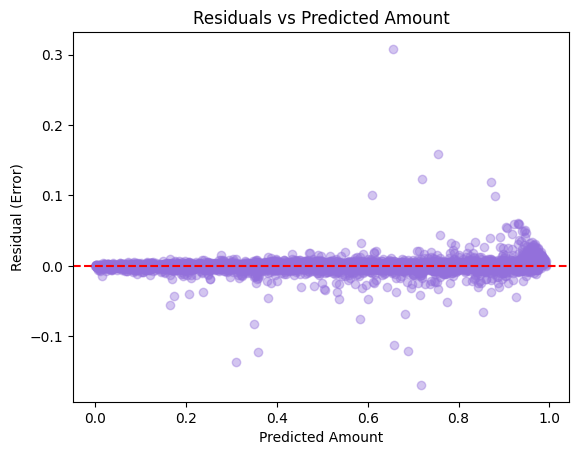

In [9]:
# 4. Residuals vs Predicted
plt.figure()
plt.scatter(preds, errors, alpha=0.4, color='mediumpurple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Amount')
plt.ylabel('Residual (Error)')
plt.title('Residuals vs Predicted Amount')

